# 05 — Point Estimation and Confidence Intervals
**References:** Fisher (1922) · Neyman & Pearson (1933) · Casella & Berger (2002) Ch. 7-8

## Narrative thread
```
Properties of estimators -> MLE -> Method of moments -> Confidence intervals -> Coverage
```

## Properties of estimators

An estimator $\hat{\theta}$ of a parameter $\theta$ should be:

| Property | Definition | Interpretation |
|---|---|---|
| **Unbiased** | $E[\hat{\theta}] = \theta$ | Right on average across samples |
| **Consistent** | $\hat{\theta} \xrightarrow{p} \theta$ as $n\to\infty$ | Converges to truth with more data |
| **Efficient** | Achieves Cramér-Rao lower bound | Minimum variance among unbiased estimators |
| **Sufficient** | Contains all information about $\theta$ in the data | No other statistic can add information |

**Bias-variance tradeoff:**
$$\text{MSE}(\hat{\theta}) = \text{Var}(\hat{\theta}) + \text{Bias}(\hat{\theta})^2$$
A biased estimator with lower variance can have lower MSE than an unbiased one.

## Maximum Likelihood Estimation (MLE)

Choose $\hat{\theta}$ to maximize the probability of the observed data:
$$\hat{\theta}_{MLE} = \arg\max_\theta \mathcal{L}(\theta; \mathbf{x}) = \arg\max_\theta \sum_{i=1}^n \log f(x_i; \theta)$$

Properties of MLE (under regularity conditions):
- **Consistent:** $\hat{\theta}_{MLE} \xrightarrow{p} \theta_0$
- **Asymptotically normal:** $\sqrt{n}(\hat{\theta}_{MLE} - \theta_0) \xrightarrow{d} N(0, I(\theta_0)^{-1})$
- **Efficient:** achieves the Cramér-Rao lower bound asymptotically
- **Equivariant:** if $\hat{\theta}$ is MLE of $\theta$, then $g(\hat{\theta})$ is MLE of $g(\theta)$

## Confidence intervals

A $(1-\alpha)\times 100\%$ **confidence interval** $[L(\mathbf{x}), U(\mathbf{x})]$ satisfies:
$$P(L(\mathbf{x}) \leq \theta \leq U(\mathbf{x})) = 1 - \alpha$$

**Correct interpretation:** if we repeated the procedure many times, $(1-\alpha)\times 100\%$
of the intervals constructed would contain the true $\theta$. It does NOT mean the probability
that *this particular interval* contains $\theta$ is $95\%$ — $\theta$ is fixed, not random.

### For the mean ($\sigma$ known): $$\bar{x} \pm z_{\alpha/2}\frac{\sigma}{\sqrt{n}}$$
### For the mean ($\sigma$ unknown): $$\bar{x} \pm t_{\alpha/2, n-1}\frac{s}{\sqrt{n}}$$

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

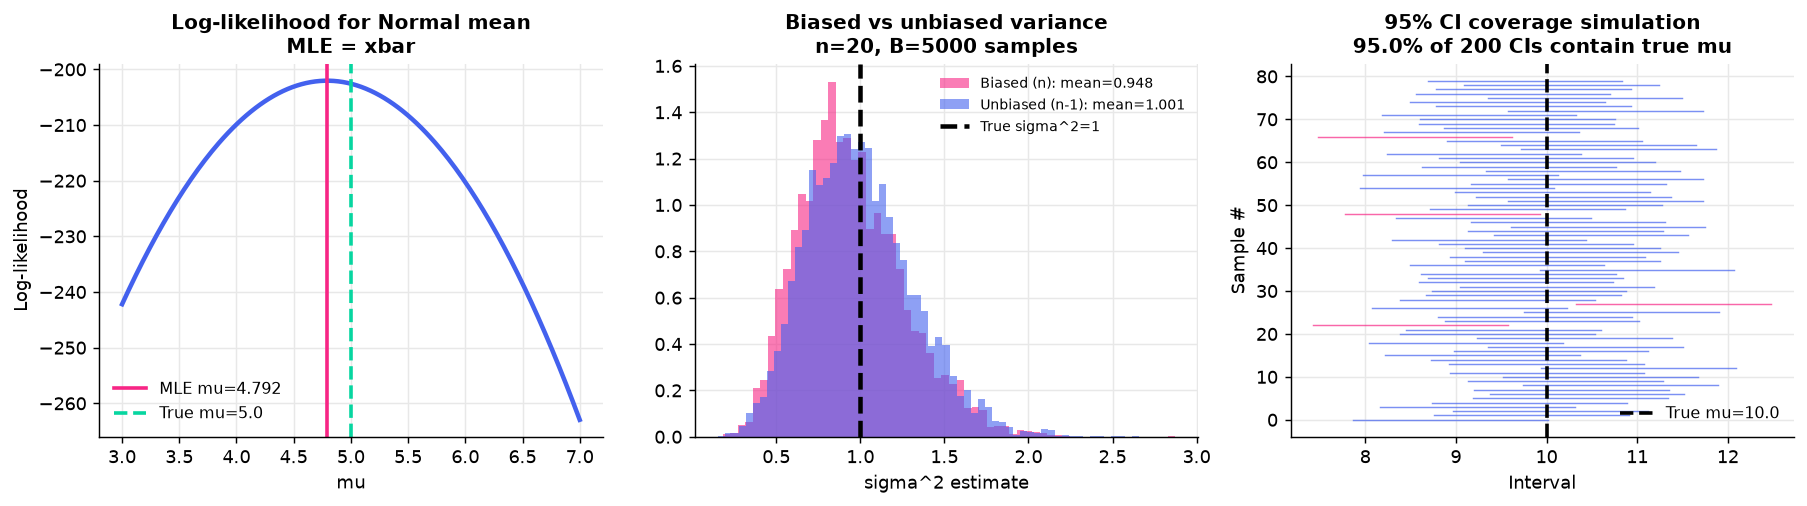

In [2]:
# ── MLE: Normal distribution ─────────────────────────────────────────────
from scipy.optimize import minimize_scalar
from scipy.stats import norm

# True parameters
mu_true, sigma_true = 5.0, 2.0
n = 100
x = np.random.normal(mu_true, sigma_true, n)

# Log-likelihood surface
mu_grid = np.linspace(3, 7, 200)
log_lik = [norm.logpdf(x, mu, sigma_true).sum() for mu in mu_grid]

mu_mle = x.mean()   # MLE for normal: xbar

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(mu_grid, log_lik, color='#4361ee', lw=2.5)
ax.axvline(mu_mle,   color='#f72585', lw=2, label=f'MLE mu={mu_mle:.3f}')
ax.axvline(mu_true,  color='#06d6a0', lw=2, linestyle='--', label=f'True mu={mu_true}')
ax.set_xlabel('mu'); ax.set_ylabel('Log-likelihood')
ax.set_title('Log-likelihood for Normal mean\nMLE = xbar')
ax.legend(fontsize=9)

# ── Bias-variance tradeoff: sample variance ───────────────────────────────
# s^2 (divide by n-1) is unbiased; biased estimator (divide by n) has lower variance
B = 5000
sigma2_unbiased = [np.random.normal(0,1,20).var(ddof=1) for _ in range(B)]
sigma2_biased   = [np.random.normal(0,1,20).var(ddof=0) for _ in range(B)]

ax2 = axes[1]
ax2.hist(sigma2_biased,   bins=60, alpha=0.6, density=True, color='#f72585', label=f'Biased (n): mean={np.mean(sigma2_biased):.3f}')
ax2.hist(sigma2_unbiased, bins=60, alpha=0.6, density=True, color='#4361ee', label=f'Unbiased (n-1): mean={np.mean(sigma2_unbiased):.3f}')
ax2.axvline(1.0, color='black', lw=2.5, linestyle='--', label='True sigma^2=1')
ax2.set_xlabel('sigma^2 estimate'); ax2.set_title('Biased vs unbiased variance\nn=20, B=5000 samples')
ax2.legend(fontsize=8)

# ── Confidence interval coverage simulation ───────────────────────────────
B_ci = 200
mu_true_ci = 10.0; sigma_ci = 3.0; n_ci = 30
cis = [(lambda s: (s.mean() - 1.96*sigma_ci/np.sqrt(n_ci),
                   s.mean() + 1.96*sigma_ci/np.sqrt(n_ci)))(np.random.normal(mu_true_ci, sigma_ci, n_ci))
       for _ in range(B_ci)]
covers = [lo <= mu_true_ci <= hi for lo, hi in cis]

ax3 = axes[2]
for i, ((lo, hi), cov) in enumerate(list(zip(cis, covers))[:80]):
    color = '#4361ee' if cov else '#f72585'
    ax3.plot([lo, hi], [i, i], color=color, lw=0.8, alpha=0.7)
ax3.axvline(mu_true_ci, color='black', lw=2, linestyle='--', label=f'True mu={mu_true_ci}')
ax3.set_xlabel('Interval'); ax3.set_ylabel('Sample #')
ax3.set_title(f'95% CI coverage simulation\n{sum(covers)/B_ci*100:.1f}% of {B_ci} CIs contain true mu')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

## MLE for common distributions

| Model | MLE |
|---|---|
| $N(\mu, \sigma^2)$ | $\hat{\mu} = \bar{x}$, $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i-\bar{x})^2$ |
| Bernoulli($p$) | $\hat{p} = \bar{x}$ |
| Poisson($\lambda$) | $\hat{\lambda} = \bar{x}$ |
| Exponential($\lambda$) | $\hat{\lambda} = 1/\bar{x}$ |

Note: the MLE for $\sigma^2$ divides by $n$, not $n-1$ — it is biased but consistent.
The unbiased estimator ($s^2$, divides by $n-1$) is preferred in practice.

## Method of Moments (MOM)

Equate population moments to sample moments and solve:
$$E[X^k] = \frac{1}{n}\sum x_i^k \quad k=1,2,\ldots$$

MOM is simpler than MLE but generally less efficient. Useful when the likelihood
is intractable.

Gamma distribution: MLE vs MOM
True:  alpha=3.0  beta=2.0
MOM:   alpha=2.9004  beta=2.1379
MLE:   alpha=3.0728  beta=2.0179


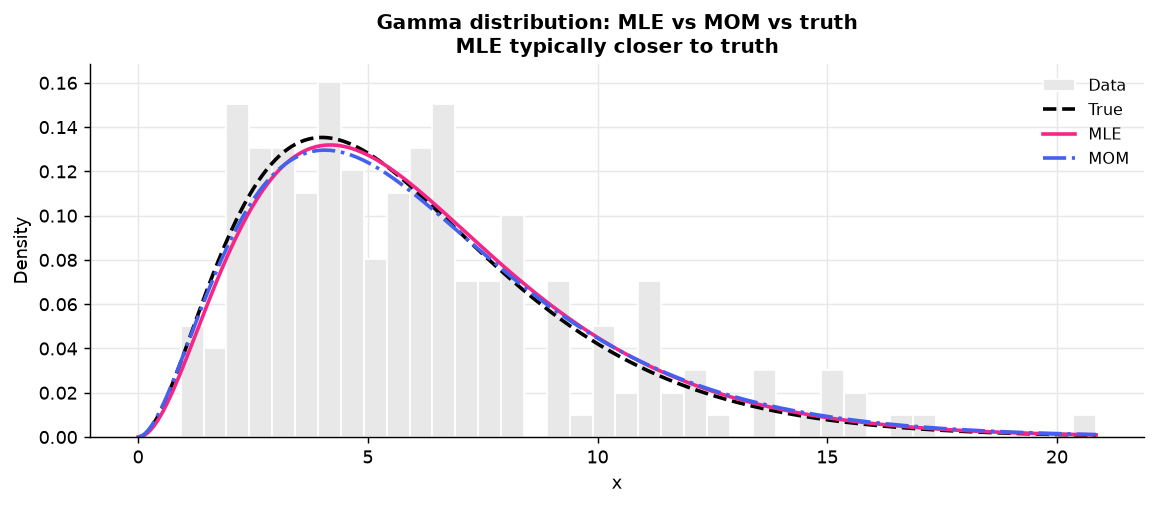

In [3]:
# ── MLE vs MOM: Gamma distribution ───────────────────────────────────────
from scipy.stats import gamma
from scipy.special import digamma
from scipy.optimize import brentq

# True parameters
alpha_true, beta_true = 3.0, 2.0   # shape, scale
x_g = np.random.gamma(alpha_true, beta_true, 200)

# MOM estimators for Gamma: E[X]=alpha*beta, Var[X]=alpha*beta^2
xbar  = x_g.mean()
s2    = x_g.var()
alpha_mom = xbar**2 / s2
beta_mom  = s2 / xbar

# MLE: solve score equations numerically
# d/d_alpha: n*(log(alpha)-digamma(alpha)) + sum(log(xi)) - n*log(xbar) = 0
log_xbar_minus_xlog = np.log(xbar) - np.log(x_g).mean()
def score_alpha(a): return np.log(a) - digamma(a) - log_xbar_minus_xlog
alpha_mle = brentq(score_alpha, 0.01, 100)
beta_mle  = xbar / alpha_mle

print('Gamma distribution: MLE vs MOM')
print(f'True:  alpha={alpha_true}  beta={beta_true}')
print(f'MOM:   alpha={alpha_mom:.4f}  beta={beta_mom:.4f}')
print(f'MLE:   alpha={alpha_mle:.4f}  beta={beta_mle:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
x_range = np.linspace(0, x_g.max(), 300)
ax.hist(x_g, bins=40, density=True, color='#e8e8e8', edgecolor='white', label='Data')
ax.plot(x_range, gamma.pdf(x_range, alpha_true, scale=beta_true), 'k--', lw=2, label='True')
ax.plot(x_range, gamma.pdf(x_range, alpha_mle,  scale=beta_mle),  color='#f72585', lw=2, label='MLE')
ax.plot(x_range, gamma.pdf(x_range, alpha_mom,  scale=beta_mom),  color='#4361ee', lw=2, linestyle='-.', label='MOM')
ax.set_xlabel('x'); ax.set_ylabel('Density')
ax.set_title('Gamma distribution: MLE vs MOM vs truth\nMLE typically closer to truth')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()